In [2]:
import os
from helpers import zenodo_get_and_unzip
from pathlib import Path
import pandas as pd
import os
import fmlib.io as fmio

save_images = False
data_folder = Path('download')
embeddings_folder = data_folder / Path('embeddings')
robustness_results_folder = data_folder / Path('embeddings_augmented_results')
os.makedirs(data_folder, exist_ok=True)



# if not learned_models_svm_folder.exists():
#     os.makedirs(learned_models_svm_folder)
#     zenodo_get_and_unzip('17898581','learned_models_svm.zip','download')

# if not learned_models_nn_folder.exists():
#     os.makedirs(learned_models_nn_folder)
#     zenodo_get_and_unzip('17898581','learned_models_nn.zip','download')


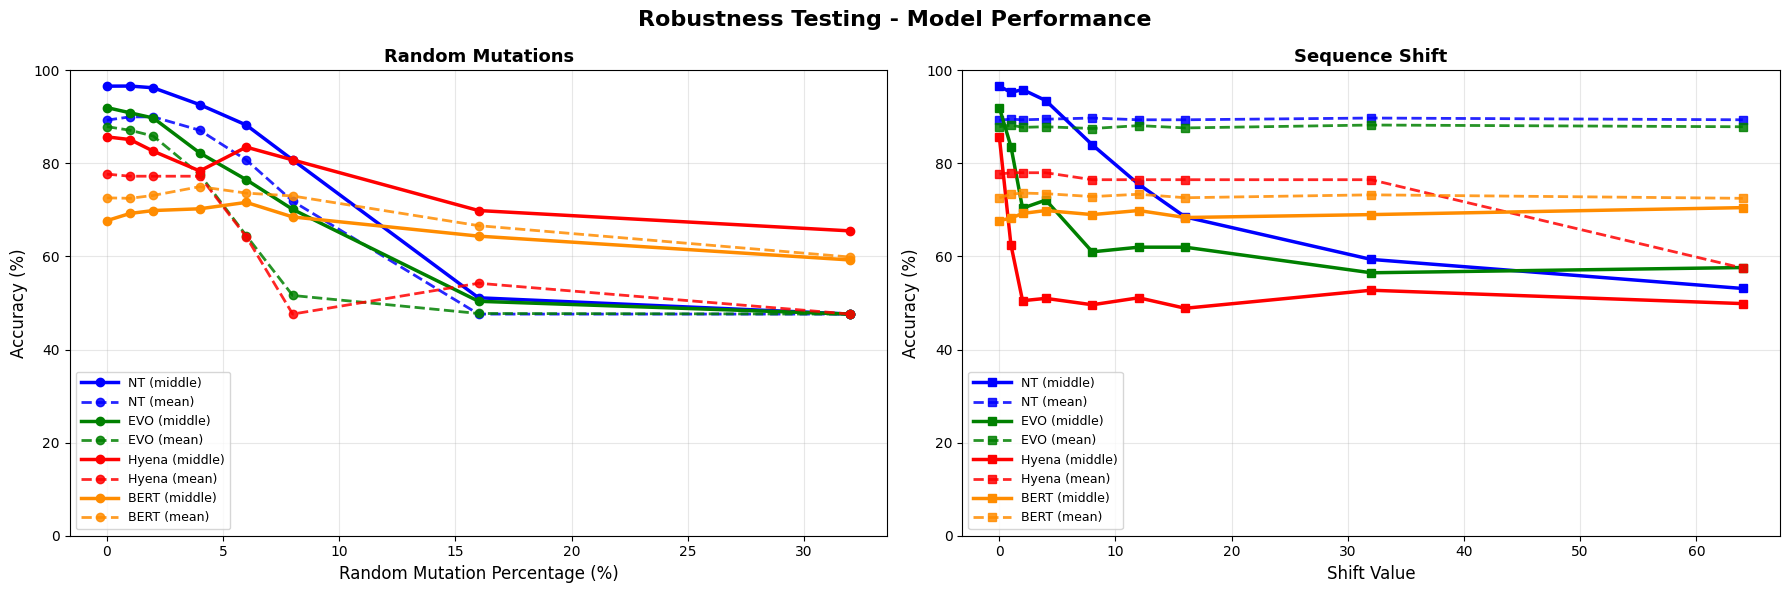

In [ ]:
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re

# Function to load results from pkl files
def load_results(file_path):
    with open(file_path, 'rb') as f:
        results = pkl.load(f)
    return results

# Function to extract mutation percentage or shift value from filename
def extract_param_from_filename(filename, param_type='rn'):
    """
    Extract parameter value from filename.
    param_type: 'rn' for random mutations, 'sh' for shift
    """
    pattern = f'{param_type}(\d+)'
    match = re.search(pattern, filename)
    if match:
        return int(match.group(1))
    return None

# Function to collect data for a specific model and augmentation type
def collect_data(model_name, aug_type, use_mean=False):
    """
    Collect accuracy data for a model across different augmentation levels.
    model_name: 'nt', 'evo', 'hyena', 'bert'
    aug_type: 'rn' (random) or 'sh' (shift)
    use_mean: True for mean embeddings, False for concatenated embeddings
    """
    # Baseline accuracies (value at 0) - converted to percentages
    baseline_values = {
        'nt': {'middle': 96.6, 'mean': 89.3},
        'evo': {'middle': 92.0, 'mean': 87.9},
        'hyena': {'middle': 85.7, 'mean': 77.7},
        'bert': {'middle': 67.7, 'mean': 72.6}
    }
    
    results_folder = robustness_results_folder
    
    # Build filename pattern
    if use_mean:
        pattern = f"{model_name}_mean_{aug_type}"
        emb_type = 'mean'
    else:
        pattern = f"{model_name}_{aug_type}"
        emb_type = 'middle'
    
    # Find all matching files
    files = list(results_folder.glob(f"{pattern}*_test_results.pkl"))
    
    data = []
    
    # Add baseline value at 0
    if model_name in baseline_values:
        baseline_acc = baseline_values[model_name][emb_type]
        data.append((0, baseline_acc))
    
    for file in files:
        param_value = extract_param_from_filename(file.name, aug_type)
        if param_value is not None:
            results = load_results(file)
            accuracy = results.get('Accuracy', None)
            if accuracy is not None:
                data.append((param_value, accuracy))
    
    # Sort by parameter value
    data.sort(key=lambda x: x[0])
    
    if data:
        params, accuracies = zip(*data)
        return list(params), list(accuracies)
    return [], []

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Robustness Testing - Model Performance', fontsize=16, fontweight='bold')

models = ['nt', 'evo', 'hyena', 'bert']
model_labels = {'nt': 'NT', 'evo': 'EVO', 'hyena': 'Hyena', 'bert': 'BERT'}
colors = {'nt': '#0000FF', 'evo': '#008000', 'hyena': '#FF0000', 'bert': '#FF8C00'}
colors_light = {'nt': '#7B9ED9', 'evo': '#7BC47B', 'hyena': '#FF8888', 'bert': '#FFC266'}

# Plot 1: Random mutations - both middle and mean embeddings
ax1 = axes[0]
for model in models:
    # Middle embeddings (darker color)
    params, accuracies = collect_data(model, 'rn', use_mean=False)
    if params:
        ax1.plot(params, accuracies, marker='o', linewidth=2.5, 
                label=f'{model_labels[model]} (middle)', color=colors[model])
    
    # Mean embeddings (lighter color)
    params, accuracies = collect_data(model, 'rn', use_mean=True)
    if params:
        ax1.plot(params, accuracies, marker='o', linewidth=2, linestyle='--',
                label=f'{model_labels[model]} (mean)', color=colors_light[model], alpha=0.85)

ax1.set_xlabel('Random Mutation Percentage (%)', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Random Mutations', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9, handlelength=3)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 100])

# Plot 2: Shift - both middle and mean embeddings
ax2 = axes[1]
for model in models:
    # Middle embeddings (darker color)
    params, accuracies = collect_data(model, 'sh', use_mean=False)
    if params:
        ax2.plot(params, accuracies, marker='s', linewidth=2.5, 
                label=f'{model_labels[model]} (middle)', color=colors[model])
    
    # Mean embeddings (lighter color)
    params, accuracies = collect_data(model, 'sh', use_mean=True)
    if params:
        ax2.plot(params, accuracies, marker='s', linewidth=2, linestyle='--',
                label=f'{model_labels[model]} (mean)', color=colors_light[model], alpha=0.85)

ax2.set_xlabel('Shift Value', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Sequence Shift', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9, handlelength=3)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 100])

plt.tight_layout()
plt.show()

# Optional: Save the figure
if save_images:
    output_path = data_folder / 'robustness_comparison.png'
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {output_path}")